In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from scipy.optimize import minimize
import os
import joblib

In [18]:
path_ad = os.path.join('..','data', 'Advertising Budget and Sales.csv')
df = pd.read_csv(path_ad, index_col=0)

# df = pd.read_csv('../data/Advertising Budget and Sales.csv', index_col=0)
print(df.head())

# Informasi tipe data dan non-null count
print("\nDATASET INFO:")
print(df.info())

   TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)  Sales ($)
1             230.1                 37.8                     69.2       22.1
2              44.5                 39.3                     45.1       10.4
3              17.2                 45.9                     69.3        9.3
4             151.5                 41.3                     58.5       18.5
5             180.8                 10.8                     58.4       12.9

DATASET INFO:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TV Ad Budget ($)         200 non-null    float64
 1   Radio Ad Budget ($)      200 non-null    float64
 2   Newspaper Ad Budget ($)  200 non-null    float64
 3   Sales ($)                200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None



Number of duplicate rows: 0
After dropping duplicates: 200 rows


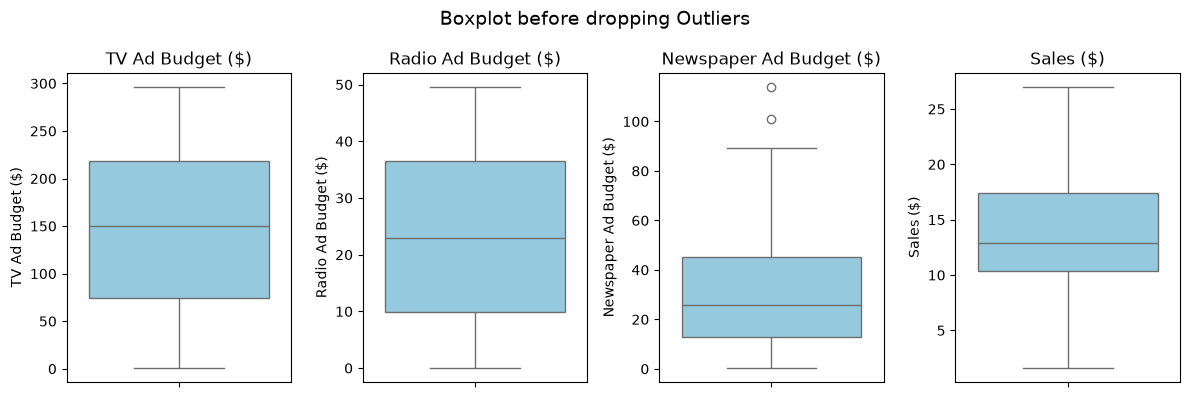


Data after dropping outliers: 198 rows (before: 200)


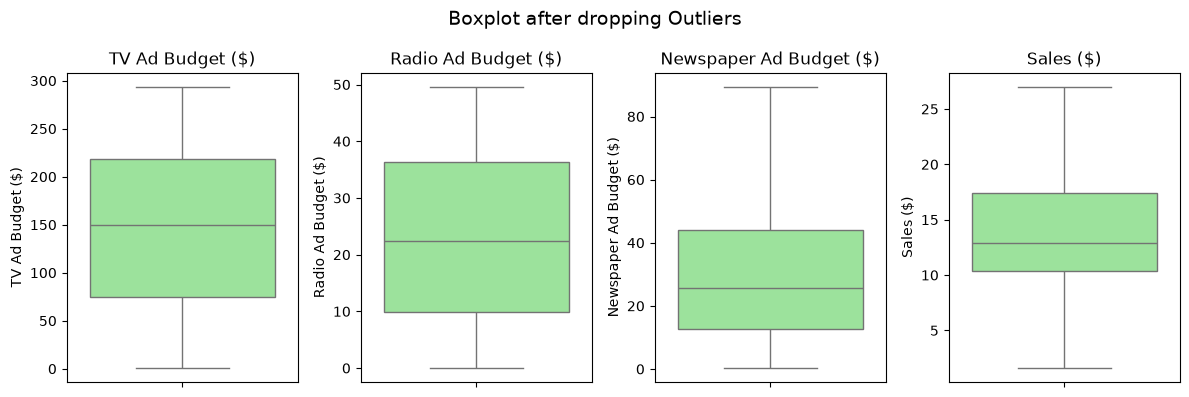


CLEAN DATA:
       TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)  \
count        198.000000           198.000000               198.000000   
mean         146.688384            23.130808                29.777273   
std           85.443221            14.862111                20.446303   
min            0.700000             0.000000                 0.300000   
25%           74.800000             9.925000                12.650000   
50%          149.750000            22.400000                25.600000   
75%          218.475000            36.325000                44.050000   
max          293.600000            49.600000                89.400000   

        Sales ($)  
count  198.000000  
mean    13.980808  
std      5.196097  
min      1.600000  
25%     10.325000  
50%     12.900000  
75%     17.375000  
max     27.000000  

Shape: (198, 4)


In [19]:
dup_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {dup_count}")
df = df.drop_duplicates()
print(f"After dropping duplicates: {df.shape[0]} rows")

plt.figure(figsize=(12, 4))
for i, col in enumerate(df.columns, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)
plt.suptitle('Boxplot before dropping Outliers', fontsize=14)
plt.tight_layout()
plt.show()

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

df_clean = df.copy()
for col in ['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']:
    df_clean = remove_outliers_iqr(df_clean, col)

print(f"\nData after dropping outliers: {df_clean.shape[0]} rows (before: {df.shape[0]})")

plt.figure(figsize=(12, 4))
for i, col in enumerate(df.columns, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df_clean[col], color='lightgreen')
    plt.title(col)
plt.suptitle('Boxplot after dropping Outliers', fontsize=14)
plt.tight_layout()
plt.show()

print("\nCLEAN DATA:")
print(df_clean.describe())
print(f"\nShape: {df_clean.shape}")

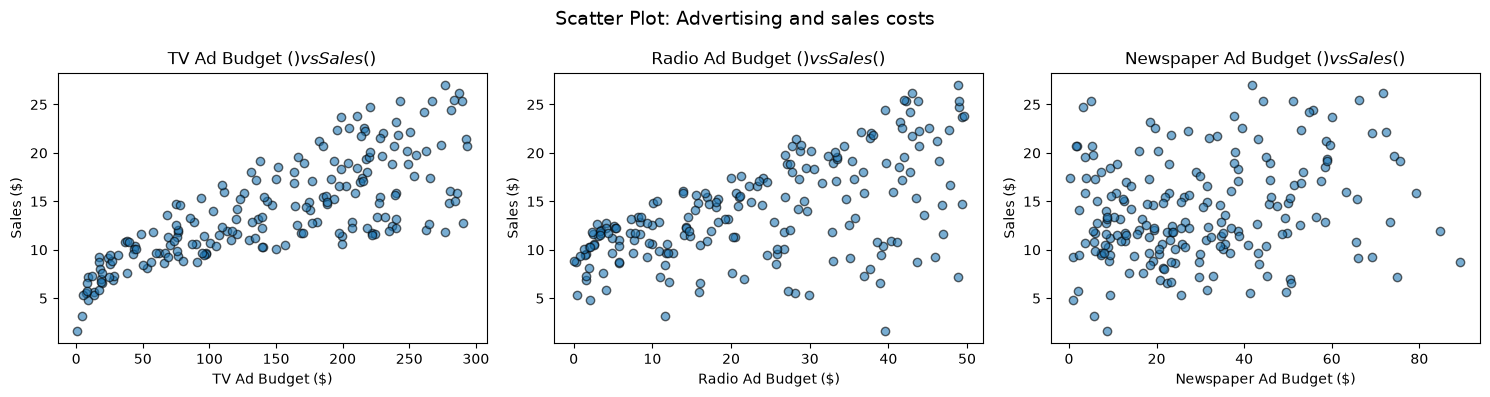

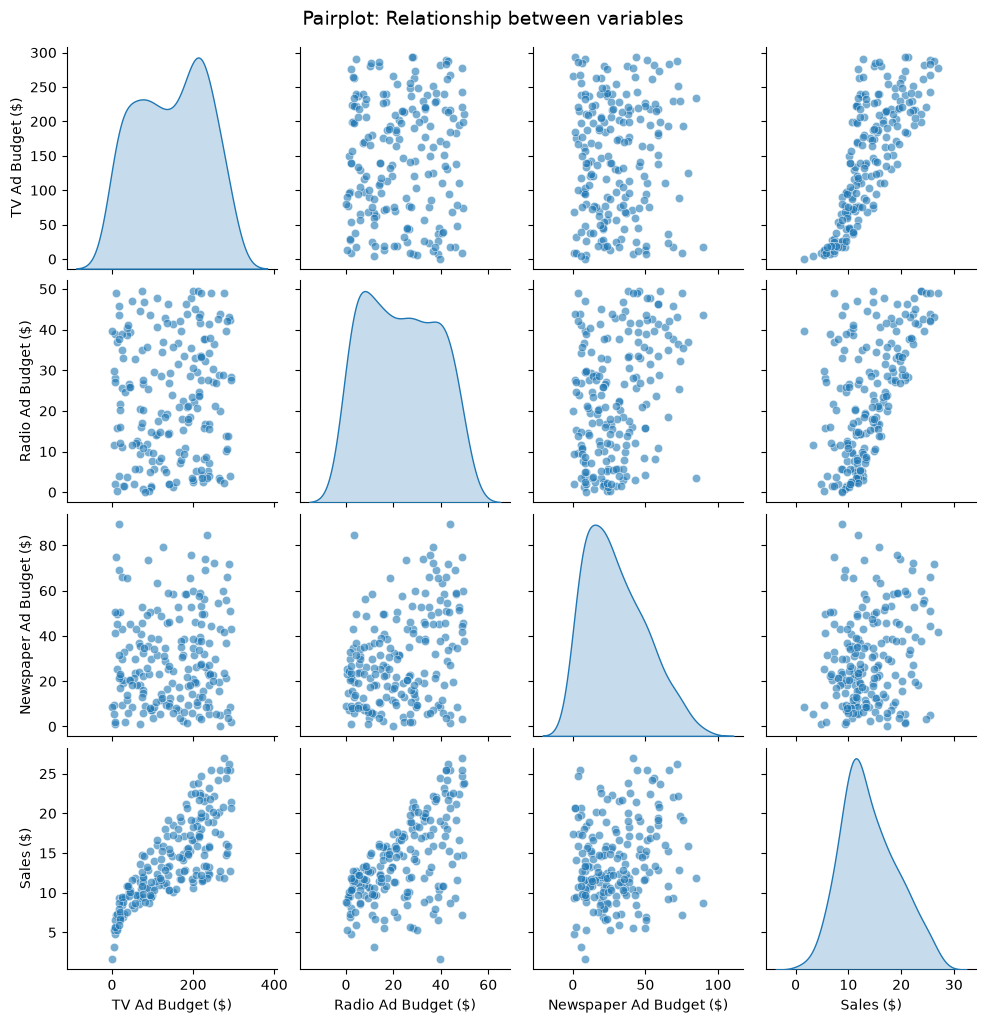

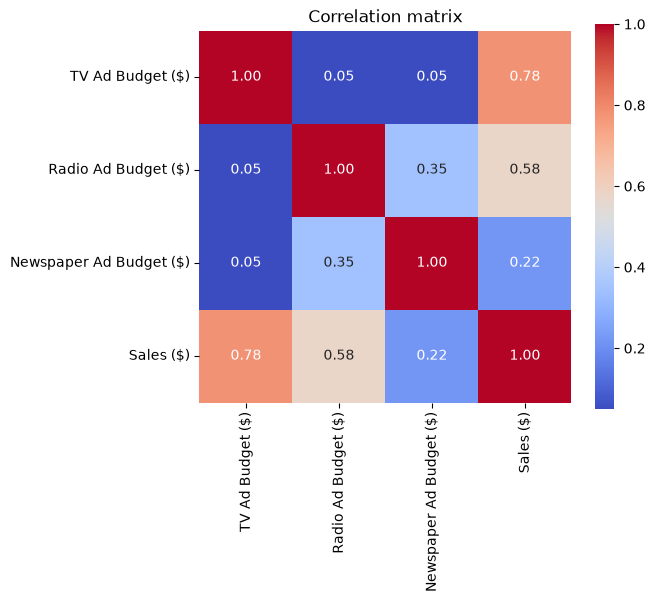

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']):
    ax.scatter(df_clean[col], df_clean['Sales ($)'], alpha=0.6, edgecolor='k')
    ax.set_xlabel(col)
    ax.set_ylabel('Sales ($)')
    ax.set_title(f'{col} vs Sales ($)')

plt.suptitle('Scatter Plot: Advertising and sales costs', fontsize=14)
plt.tight_layout()
plt.show()

sns.pairplot(df_clean, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot: Relationship between variables', y=1.02, fontsize=14)
plt.show()

corr_matrix = df_clean.corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation matrix')
plt.show()

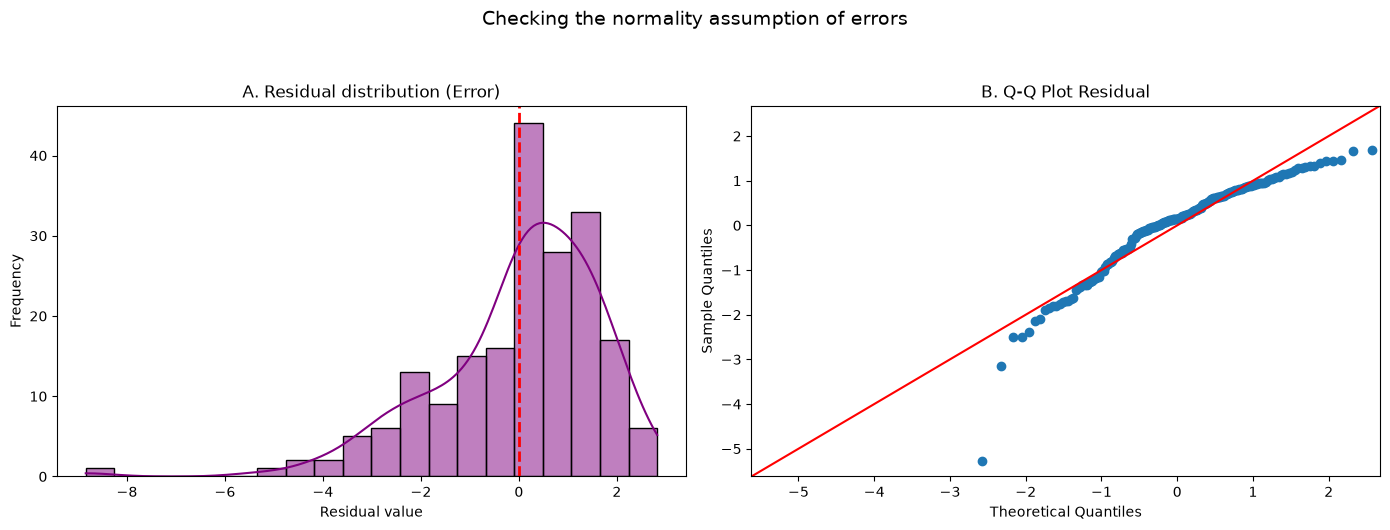

Average Residual: 0.0000 (Idelly close to 0)


In [21]:
X = df_clean[['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']]
y = df_clean['Sales ($)']

model_baseline = LinearRegression()
model_baseline.fit(X, y)

y_pred = model_baseline.predict(X)
residuals = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, kde=True, ax=axes[0], color='purple', bins=20)
axes[0].set_title('A. Residual distribution (Error)', fontsize=12)
axes[0].set_xlabel('Residual value')
axes[0].set_ylabel('Frequency')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2) 

sm.qqplot(residuals, line='45', fit=True, ax=axes[1])
axes[1].set_title('B. Q-Q Plot Residual', fontsize=12)

plt.suptitle('Checking the normality assumption of errors', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# 5. Cek rata-rata error
print(f"Average Residual: {residuals.mean():.4f} (Idelly close to 0)")

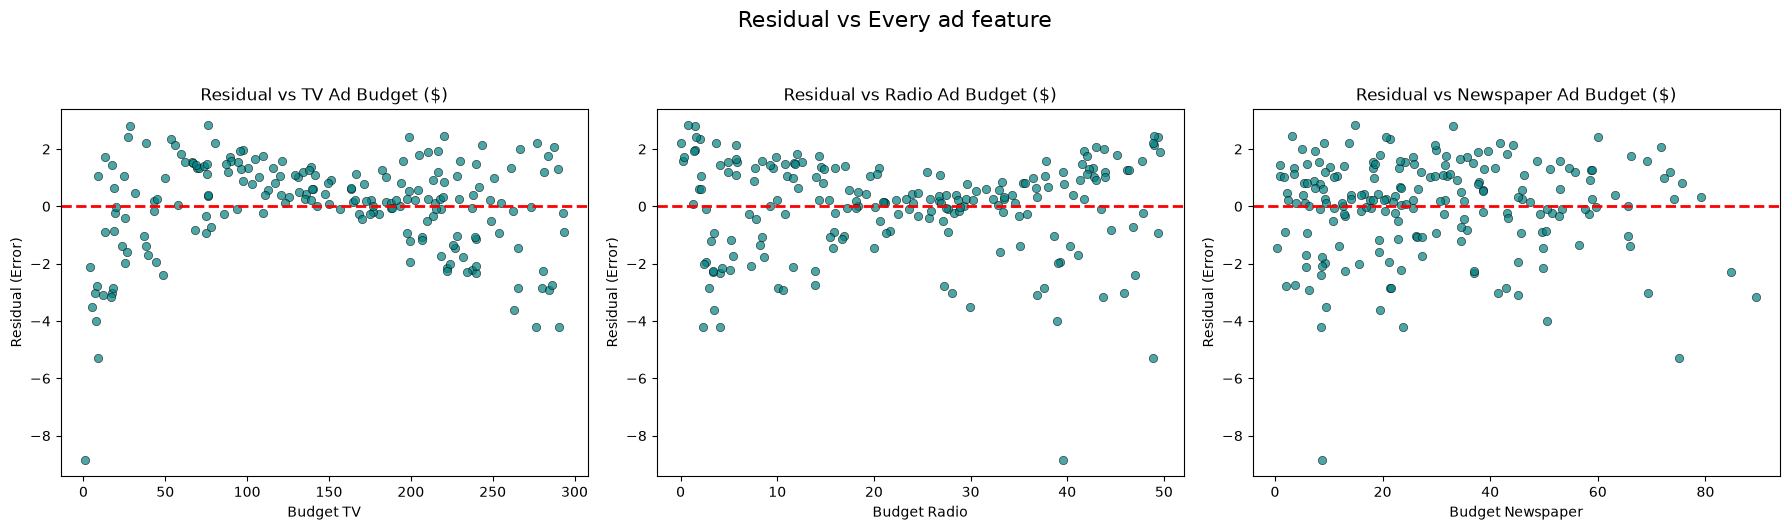

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
Ad_feature = ['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper Ad Budget ($)']

for ax, col in zip(axes, Ad_feature):
    sns.scatterplot(x=df_clean[col], y=residuals, ax=ax, alpha=0.7, edgecolor='k', color='teal')
    
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    
    ax.set_title(f'Residual vs {col}', fontsize=12)
    ax.set_xlabel(f'Budget {col.split()[0]}')
    ax.set_ylabel('Residual (Error)')

plt.suptitle('Residual vs Every ad feature', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [23]:
df_model = df_clean.copy()

max_tv = df_model['TV Ad Budget ($)'].max()
max_radio = df_model['Radio Ad Budget ($)'].max()
max_news = df_model['Newspaper Ad Budget ($)'].max()

df_model['Newspaper_log'] = np.log1p(df_model['Newspaper Ad Budget ($)'])

X = df_model[['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper_log']]
y = df_model['Sales ($)']

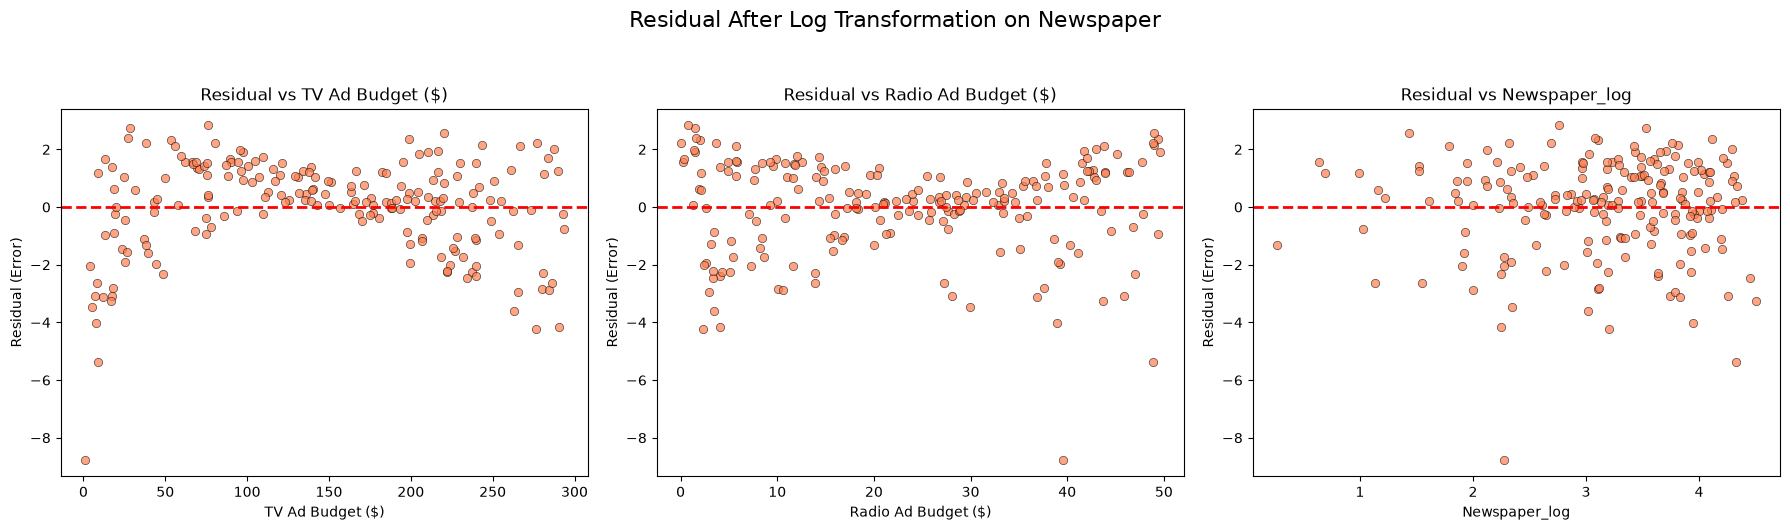

In [24]:
temp_model = LinearRegression()
temp_model.fit(X, y)

y_pred_temp = temp_model.predict(X)
residuals_temp = y - y_pred_temp

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fitur_baru = ['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper_log']

for ax, col in zip(axes, fitur_baru):
    sns.scatterplot(x=df_model[col], y=residuals_temp, ax=ax, alpha=0.7, edgecolor='k', color='coral')
    
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    
    ax.set_title(f'Residual vs {col}', fontsize=12)
    # Merapikan nama label X
    ax.set_xlabel(col)
    ax.set_ylabel('Residual (Error)')

plt.suptitle('Residual After Log Transformation on Newspaper', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline_log = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lasso', LassoCV(cv=5, random_state=42, max_iter=10000))
])

y_train_log = np.log1p(y_train)
pipeline_log.fit(X_train, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](3,)","['TV Ad Budget ($)','Radio Ad Budget ($)','Newspaper_log']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,3
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [26]:
#joblib.dump(pipeline_log, 'pipeline_lasso_poly.pkl')

In [27]:
y_pred_test = np.expm1(pipeline_log.predict(X_test))

rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)
print(f"Log Sales Model -> RMSE Test: {rmse:.3f}, R² Test: {r2:.3f}")

feature_names = pipeline_log.named_steps['poly'].get_feature_names_out(['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper_log'])
coefs = pipeline_log.named_steps['lasso'].coef_
selected = pd.Series(coefs, index=feature_names)
print("\nSelected Feature (coefficient != 0):")
print(selected[selected != 0].sort_values())

Log Sales Model -> RMSE Test: 0.852, R² Test: 0.973

Selected Feature (coefficient != 0):
TV Ad Budget ($)^2                     -0.111048
TV Ad Budget ($) Newspaper_log         -0.027903
Radio Ad Budget ($)^2                  -0.010837
Radio Ad Budget ($) Newspaper_log       0.004293
Newspaper_log                           0.016091
TV Ad Budget ($) Radio Ad Budget ($)    0.060935
Radio Ad Budget ($)                     0.172602
TV Ad Budget ($)                        0.266973
dtype: float64


In [28]:
total_budget = 400

bounds = [(0, max_tv), (0, max_radio), (0, max_news)]

def predict_sales(spends):
    tv, radio, news = spends
    news_log = np.log1p(news)
    input_df = pd.DataFrame([[tv, radio, news_log]],
                            columns=['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper_log'])
    log_pred = pipeline_log.predict(input_df)[0]
    return np.expm1(log_pred)

cons = ({'type': 'eq', 'fun': lambda x: total_budget - np.sum(x)})

best_sales = -np.inf
best_x = None

guesses = [
    [total_budget/2, total_budget/4, total_budget/4],
    [total_budget*0.7, total_budget*0.2, total_budget*0.1],
    [max_tv*0.8, max_radio*0.5, total_budget - max_tv*0.8 - max_radio*0.5]
]

for guess in guesses:
    guess = np.clip(guess, [b[0] for b in bounds], [b[1] for b in bounds])
    res = minimize(lambda x: -predict_sales(x), guess, bounds=bounds, constraints=cons, method='SLSQP')
    if res.success and -res.fun > best_sales:
        best_sales = -res.fun
        best_x = res.x
 
if best_x is not None:
    print("\n=== PROFIT OPTIMIZATION (LOG MODEL) ===")
    print(f"Total Budget : ${total_budget:,.2f}")
    print(f"TV          : ${best_x[0]:.2f}  ({best_x[0]/total_budget*100:.1f}%)")
    print(f"Radio       : ${best_x[1]:.2f}  ({best_x[1]/total_budget*100:.1f}%)")
    print(f"Newspaper   : ${best_x[2]:.2f}  ({best_x[2]/total_budget*100:.1f}%)")
    print(f"Maximum Sales Prediction: {best_sales:.2f}")
else:
    print("Optimization Failed.")


=== PROFIT OPTIMIZATION (LOG MODEL) ===
Total Budget : $400.00
TV          : $293.60  (73.4%)
Radio       : $49.60  (12.4%)
Newspaper   : $56.80  (14.2%)
Maximum Sales Prediction: 26.86


In [29]:
max_tv = df_model['TV Ad Budget ($)'].max()      # 293.6
max_radio = df_model['Radio Ad Budget ($)'].max()# 49.6
max_news = df_model['Newspaper Ad Budget ($)'].max()  # 89.4 (real)
total_max = max_tv + max_radio + max_news         # ~432.6

def predict_sales(spends):
    tv, radio, news = spends
    news_log = np.log1p(news)
    input_df = pd.DataFrame([[tv, radio, news_log]],
                            columns=['TV Ad Budget ($)', 'Radio Ad Budget ($)', 'Newspaper_log'])
    log_pred = pipeline_log.predict(input_df)[0]
    return np.expm1(log_pred)

budgets = np.arange(200, 451, 25)  # 200, 225, ..., 450
results = [] 

bounds = [(0, max_tv), (0, max_radio), (0, max_news)]

for total_budget in budgets:
    cons = {'type': 'ineq', 'fun': lambda x: total_budget - np.sum(x)}

    best_sales = -np.inf
    best_x = None

    g1 = [min(total_budget/2, max_tv), min(total_budget/4, max_radio), min(total_budget/4, max_news)]
    g2 = [min(total_budget*0.7, max_tv), min(total_budget*0.2, max_radio), min(total_budget*0.1, max_news)]
    g3 = [min(max_tv*0.8, total_budget*0.6), min(max_radio*0.5, total_budget*0.2), min(max_news, total_budget*0.2)]

    for guess in [g1, g2, g3]:
        guess = np.clip(guess, [0,0,0], [max_tv, max_radio, max_news])
        res = minimize(lambda x: -predict_sales(x), guess, bounds=bounds, constraints=cons, method='SLSQP')
        if res.success and -res.fun > best_sales:
            best_sales = -res.fun
            best_x = res.x

    if best_x is not None:
        results.append({
            'Budget': total_budget,
            'TV': best_x[0],
            'Radio': best_x[1],
            'Newspaper': best_x[2],
            'Sales': best_sales,
            'Total_Spent': np.sum(best_x) 
        })
        print(f"Budget ${total_budget:3.0f} -> Sales ${best_sales:.2f} | TV={best_x[0]:.0f}, Radio={best_x[1]:.0f}, News={best_x[2]:.0f} (Spent ${np.sum(best_x):.0f})")
    else:
        print(f"Budget ${total_budget:3.0f}: Optimasi gagal.")

df_res = pd.DataFrame(results)
print("\nResults Table:")
print(df_res.round(2))

Budget $200 -> Sales $18.79 | TV=146, Radio=50, News=5 (Spent $200)
Budget $225 -> Sales $21.21 | TV=172, Radio=50, News=3 (Spent $225)
Budget $250 -> Sales $23.53 | TV=199, Radio=50, News=1 (Spent $250)
Budget $275 -> Sales $25.78 | TV=225, Radio=50, News=0 (Spent $275)
Budget $300 -> Sales $27.74 | TV=250, Radio=50, News=0 (Spent $300)
Budget $325 -> Sales $29.27 | TV=275, Radio=50, News=0 (Spent $325)
Budget $350 -> Sales $30.06 | TV=294, Radio=50, News=0 (Spent $343)
Budget $375 -> Sales $30.06 | TV=294, Radio=50, News=0 (Spent $343)
Budget $400 -> Sales $30.06 | TV=294, Radio=50, News=0 (Spent $343)
Budget $425 -> Sales $30.06 | TV=294, Radio=50, News=0 (Spent $343)
Budget $450 -> Sales $30.06 | TV=294, Radio=50, News=0 (Spent $343)

Results Table:
    Budget      TV  Radio  Newspaper  Sales  Total_Spent
0      200  145.77   49.6       4.63  18.79        200.0
1      225  172.15   49.6       3.25  21.21        225.0
2      250  199.20   49.6       1.20  23.53        250.0
3      2

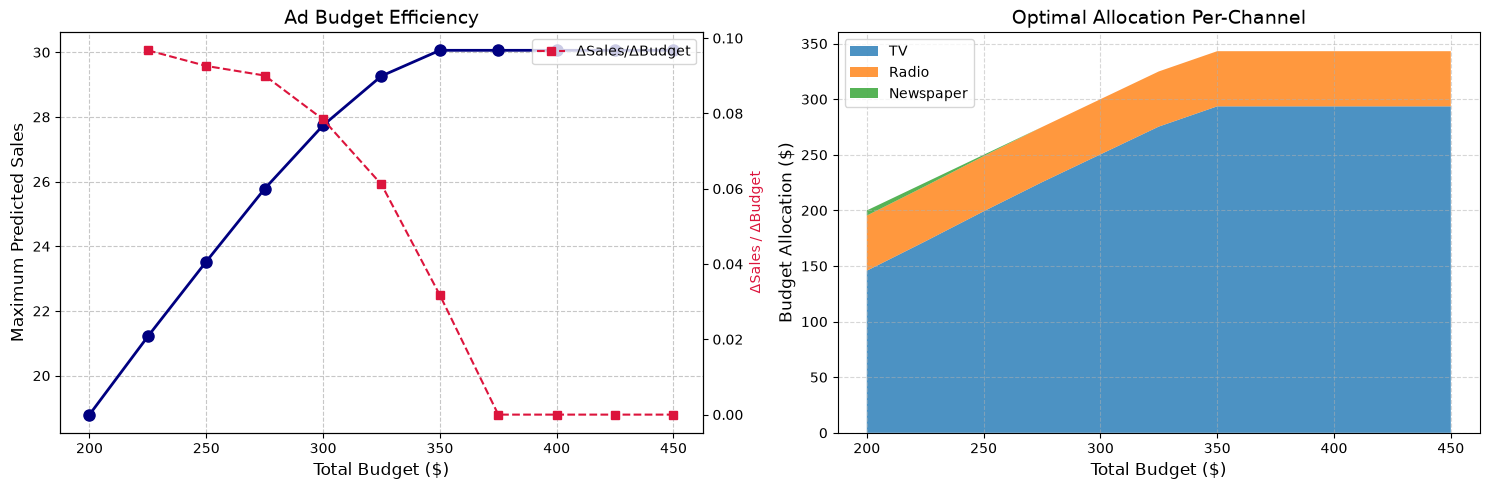

In [30]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(df_res['Budget'], df_res['Sales'], 'o-', color='navy', linewidth=2, markersize=8)
ax1.set_xlabel('Total Budget ($)', fontsize=12)
ax1.set_ylabel('Maximum Predicted Sales', fontsize=12)
ax1.set_title('Ad Budget Efficiency', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.7)

ax1b = ax1.twinx()
marginal = np.diff(df_res['Sales']) / np.diff(df_res['Budget'])
ax1b.plot(df_res['Budget'].iloc[1:], marginal, 's--', color='crimson', label='ΔSales/ΔBudget')
ax1b.set_ylabel('ΔSales / ΔBudget', color='crimson')
ax1b.legend(loc='upper right')

ax2.stackplot(df_res['Budget'], 
              df_res['TV'], df_res['Radio'], df_res['Newspaper'],
              labels=['TV','Radio','Newspaper'],
              colors=['#1f77b4','#ff7f0e','#2ca02c'], alpha=0.8)
ax2.set_xlabel('Total Budget ($)', fontsize=12)
ax2.set_ylabel('Budget Allocation ($)', fontsize=12)
ax2.set_title('Optimal Allocation Per-Channel', fontsize=14)
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [31]:
threshold = 0.005
saturated = df_res[df_res['Budget'].diff() > 0]  
marginal_series = np.diff(df_res['Sales']) / np.diff(df_res['Budget'])

df_res['Marginal'] = [np.nan] + list(marginal_series)

print("\nMarginal Efficiency Per Additional $25 Budget:")
print(df_res[['Budget','Sales','Marginal']].round(4))

below_threshold = df_res[df_res['Marginal'] < threshold]
if not below_threshold.empty:
    saturated_budget = below_threshold.iloc[0]['Budget']
    print(f"\nThe saturation point is reached around = ${saturated_budget:.0f}")
else:
    print("\nHasn't reached a saturation point within this budget range.")


Marginal Efficiency Per Additional $25 Budget:
    Budget    Sales  Marginal
0      200  18.7942       NaN
1      225  21.2131    0.0968
2      250  23.5281    0.0926
3      275  25.7796    0.0901
4      300  27.7396    0.0784
5      325  29.2676    0.0611
6      350  30.0607    0.0317
7      375  30.0607   -0.0000
8      400  30.0607    0.0000
9      425  30.0607    0.0000
10     450  30.0607    0.0000

The saturation point is reached around = $375
